In [1]:
import os
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    api_key=os.getenv("AICREDITS_API_KEY"),
    base_url="https://api.aicredits.in/v1",  # Explicitly standardizing the base_url
    model="gemini-2.0-flash-lite"
)

#test
response = llm.invoke("Test query")
print(response.content)

OK, I'm ready. Please provide your test query! I'll do my best to understand and respond to it.

What would you like to test?


In [5]:
job_description: str = ""
prompt_template = (
    "Given a job description, decide whether it suites a junior Java developer."
    "\nJOB DESCRIPTION:\n{job_description}\n")
result = llm.invoke(prompt_template.format(job_description = job_description))
print(result)

content='Okay, I\'m ready! Please provide me with the job description. I will analyze it and tell you whether it seems suitable for a junior Java developer.\n\nTo help me do the best job, try to include as much detail as possible in the job description, such as:\n\n*   **Job Title:** (e.g., Junior Java Developer, Software Engineer - Java)\n*   **Responsibilities:** What will the developer be doing day-to-day?\n*   **Required Skills/Qualifications:** What technologies, languages, frameworks, and experience are they looking for?\n*   **Preferred Skills/Qualifications:** What are the "nice-to-haves"?\n*   **Experience Level:** Is there a specific number of years of experience mentioned?\n*   **Company/Project Context:** Any hints about the type of company or project?\n\nOnce you provide the description, I\'ll look for keywords and phrases that indicate whether the role is geared towards someone starting their career in Java development.' additional_kwargs={'refusal': None} response_metada

In [6]:
job_description = """
SPS-Software Engineer (m/w/d) im Maschinenbau
Glaston Germany GmbH
Neuhausen-Hamberg
Feste Anstellung
Homeoffice möglich, Vollzeit
Erschienen: vor 1 Tag
Glaston Germany GmbH logo
SPS-Software Engineer (m/w/d) im Maschinenbau
Glaston Germany GmbH
slide number 1slide number 2slide number 3
Glaston ist eine internationale Marke mit weltweit führenden Unternehmen, die für zukunftsweisende Maschinen, Anlagen, Systeme und Dienstleistungen in der Bearbeitung von Architektur-, Fahrzeug- und Displayglas steht.

Mit unserer über 50-jährigen Erfahrung am Standort Glaston Germany GmbH in Neuhausen bei Pforzheim verbessern und sichern wir nachhaltig die Produktivität unserer Kunden bei der Fertigung von Architekturglas. Diesen Erfolg verdanken wir unseren motivierten und engagierten Mitarbeitenden und wurden so zu einem der führenden Anbieter von automatisierten und kundenspezifischen Anlagen.

Der Umgang mit Software liegt dir im Blut und du möchtest bei einem Hidden Champion durchstarten?
Dein Faible für Softwarelösungen und dein Herz für unterschiedliche Technologien sind ideale Voraussetzungen, um Maschinen wieder zu alter Stärke zu verhelfen?
Du hast einen ausgeprägten Servicegedanken und Spaß an der Arbeit mit Kunden?

Dann komm zu Glaston! Wir suchen ab sofort für unseren Bereich Service Upgrades Verstärkung!

SPS-SOFTWARE ENGINEER (M/W/D) IM MASCHINENBAU

Als SPS-Software Engineer (m/w/d) im Maschinenbau sind deine Aufgabengebiete:
Ausarbeitung und Weiterentwicklung von Kundenaufträgen und Upgrade-Konzepten
Selbstständige und termingerechte Bearbeitung von Kundenprojekten und Bereitstellung der notwendigen Dokumente
Unterstützung des Inbetriebnahme- und Servicepersonals im Haus und beim Kunden vor Ort
Diese Anforderungen musst du mitbringen:
Qualifizierte technische Ausbildung: Techniker, Studium oder vergleichbare Qualifikation
Mehrjährige Berufserfahrung im Serviceumfeld, idealerweise im Maschinen- und Anlagenbau
Umfangreiche Kenntnisse in verschiedenen SPS-Programmiersprachen (z.B. S7Classic, TIA, Simotion)
Bei uns profitierst du von folgenden Benefits:
Exzellente Rahmenbedingungen (z.B. attraktives Gehaltsmodell, flexible Arbeitszeiten mit Gleitzeit und Homeoffice-Möglichkeiten)
Attraktives Arbeitsumfeld in idyllisch-ländlicher Lage
Umfangreiche Mobilitätsförderung (z.B. Ladestation für Elektroautos)
Wellbeing am Arbeitsplatz
"""

In [7]:
prompt_template_enum = (
    "Given a job description, decide whether it suites a junior Java developer."
    "\nJOB DESCRIPTION:\n{job_description}\n\nAnswer only YES or NO."
)
result = llm.invoke(prompt_template_enum.format(job_description=job_description))
print(result.content)

NO


### Building a parser that parses and output into enum

In [13]:
from enum import Enum
from typing import Any
from langchain_core.output_parsers import BaseOutputParser
from langchain_core.messages import HumanMessage

# Custom drop-in replacement for the deprecated EnumOutputParser
class EnumOutputParser(BaseOutputParser[Enum]):
    enum: Any

    def __init__(self, enum: Any, **kwargs: Any):
        super().__init__(enum=enum, **kwargs)

    def parse(self, text: str) -> Enum:
        # Strip whitespaces/newlines and map to the Enum class
        return self.enum(text.strip())


class IsSuitableJobEnum(Enum):
    YES = "YES"
    NO = "NO"

parser = EnumOutputParser(enum=IsSuitableJobEnum)

# All assertions pass perfectly:
assert parser.invoke("NO") == IsSuitableJobEnum.NO
assert parser.invoke("YES\n") == IsSuitableJobEnum.YES
assert parser.invoke(" YES \n") == IsSuitableJobEnum.YES
assert parser.invoke(HumanMessage(content="YES")) == IsSuitableJobEnum.YES

print("All tests passed successfully!")


All tests passed successfully!


In [14]:
chain = llm | parser

result = chain.invoke(prompt_template_enum.format(job_description=job_description))
print(result)

IsSuitableJobEnum.NO


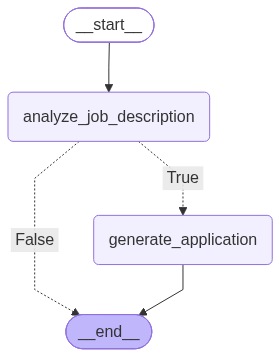

In [15]:
from typing_extensions import TypedDict
from langchain_core.runnables.config import RunnableConfig
from langgraph.graph import StateGraph, START, END

class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: IsSuitableJobEnum
    application: str

analyze_chain = llm | parser

def analyze_job_description(state):
    prompt = prompt_template_enum.format(job_description=state["job_description"])
    result = analyze_chain.invoke(prompt)
    return result

def is_suitable_condition(state: JobApplicationState):
    return state["is_suitable"] == IsSuitableJobEnum.YES

def generate_application(state):
    print("...generating application...")
    return {"application": "some_fake_application", "actions": ["action2"]}

builder = StateGraph(JobApplicationState)
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)

builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges("analyze_job_description", is_suitable_condition,
                              {True: "generate_application", False: END})
builder.add_edge("generate_application", END)


graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))